# Task 4: Forecasting Access and Usage, 2025-2027
**Ethiopia Financial Inclusion Forecasting — Selam Analytics**

Objective: forecast Account Ownership (Access) and Digital Payment Usage (Usage) for
2025-2027, with honest uncertainty bands, building directly on Task 3's calibrated
event-impact model (`src/impact_model.py`, `src/forecast.py`).


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

from src.data_loader import load_unified_data, load_reference_codes, get_observations, get_events
from src.enrichment import add_record, append_log_entry
from src.impact_model import get_effects_for_indicator, build_association_matrix
from src.forecast import fit_trend, trend_prediction, event_augmented_forecast, scenario_forecast

COLLECTED_BY = "Meron Sisay"
COLLECTION_DATE = "2026-07-20"

df = load_unified_data()
print(f"Loaded {len(df)} records")

# Reuse Task 3's calibration rather than re-deriving it
calibration = pd.read_csv(PROCESSED_DIR / "impact_model_calibration.csv")
CALIBRATED_DAMPENING = calibration["calibrated_dampening"].iloc[0]
print(f"calibrated dampening factor: {CALIBRATED_DAMPENING:.3f}")


Loaded 75 records
calibrated dampening factor: 0.342


### Closing a gap before forecasting: the missing 2011 data point

The project brief frames this as forecasting from **"5 Findex points over 13 years"**
(2011-2024), but the dataset (per Task 2's gap analysis) only has 4 `ACC_OWNERSHIP` points —
2011 is missing. The brief's own overview table cites it (14%, 2011). Adding it now, sourced
directly, since a 5th real point meaningfully improves the trend regression this whole task
depends on.


In [2]:
df, added = add_record(df, {
    "record_type": "observation", "pillar": "ACCESS",
    "indicator": "Account Ownership Rate", "indicator_code": "ACC_OWNERSHIP",
    "value_numeric": 14.0, "value_type": "percentage", "unit": "%",
    "observation_date": "2011-12-31", "gender": "all", "location": "national",
    "source_name": "Global Findex 2011", "source_type": "survey",
    "source_url": "https://www.worldbank.org/en/publication/globalfindex",
    "confidence": "high",
    "original_text": "Account ownership in Ethiopia was 14% in 2011 (Global Findex).",
    "notes": ("Fills the gap identified in Task 2 -- the project brief frames the whole "
              "forecasting task around '5 Findex points over 13 years', but only 4 existed "
              "in the dataset before this addition."),
})
if added:
    append_log_entry(
        record_id=df.iloc[-1]["record_id"], record_type="observation",
        description="Account Ownership Rate, 2011 (closes the 5th-point gap)",
        source_url="https://www.worldbank.org/en/publication/globalfindex",
        original_text="Account ownership in Ethiopia was 14% in 2011 (Global Findex).",
        confidence="high", collected_by=COLLECTED_BY, collection_date=COLLECTION_DATE,
        notes="Needed for Task 4's trend regression to actually use the full 2011-2024 span the brief describes.",
    )
    print(f"Added {df.iloc[-1]['record_id']}")
else:
    print("Skipped (already present): ACC_OWNERSHIP 2011")

# Persist immediately -- otherwise this addition only exists for the lifetime of this
# notebook's kernel, the same mistake caught and fixed in notebook 03.
raw_path = Path.cwd().parent / "data" / "raw" / "ethiopia_fi_unified_data.csv"
df.to_csv(raw_path, index=False)
print(f"Saved {len(df)} records to {raw_path}")


Added REC_0046
Saved 75 records to c:\Users\sisay\OneDrive\Documents\kaim\ethiopia-fi-forecast\data\raw\ethiopia_fi_unified_data.csv


## 1. Define Targets

- **Access** (`ACC_OWNERSHIP`): % of adults with an account at a financial institution or
  using mobile money — now 5 points, 2011-2024.
- **Usage** (`USG_DIGITAL_PAYMENT`): % of adults who made or received a digital payment —
  only 2 points, 2021 and 2024. This asymmetry in data volume matters and is carried forward
  honestly into the uncertainty bands below, not smoothed over.


In [3]:
acc_obs = get_observations(df, pillar="ACCESS")
acc_series = acc_obs[(acc_obs["indicator_code"] == "ACC_OWNERSHIP") & (acc_obs["gender"] == "all")].sort_values("observation_date")
usg_series = get_observations(df)[get_observations(df)["indicator_code"] == "USG_DIGITAL_PAYMENT"].sort_values("observation_date")

print("ACCESS (ACC_OWNERSHIP):")
print(acc_series[["value_numeric", "observation_date"]].to_string(index=False))
print(f"\n{len(acc_series)} points over {(acc_series['observation_date'].max() - acc_series['observation_date'].min()).days / 365.25:.0f} years")
print("\nUSAGE (USG_DIGITAL_PAYMENT):")
print(usg_series[["value_numeric", "observation_date"]].to_string(index=False))
print(f"\n{len(usg_series)} points over {(usg_series['observation_date'].max() - usg_series['observation_date'].min()).days / 365.25:.0f} years")


ACCESS (ACC_OWNERSHIP):
 value_numeric observation_date
          14.0       2011-12-31
          22.0       2014-12-31
          35.0       2017-12-31
          46.0       2021-12-31
          49.0       2024-11-29

5 points over 13 years

USAGE (USG_DIGITAL_PAYMENT):
 value_numeric observation_date
          23.0       2021-12-31
          21.0       2024-11-29

2 points over 3 years


## 2. Select Approach

Given how sparse both series are, three approaches are combined rather than picking just one:

1. **Trend regression** (OLS, linear in years) — a defensible baseline, with a real caveat:
   `USG_DIGITAL_PAYMENT` has exactly 2 points, meaning **zero residual degrees of freedom** —
   its "confidence interval" is not statistically meaningful the way `ACC_OWNERSHIP`'s
   (5 points, 3 degrees of freedom) is. Both are still fit, but Usage's interval is
   deliberately widened further in the scenario step to reflect this honestly.
2. **Event-augmented model** — Task 3's calibrated ramp model layered on top of the trend,
   capturing the incremental effect of events whose ramp isn't yet fully realized as of the
   last actual data point (e.g. EthioPay's Dec 2025 launch, the M-Pesa-EthSwitch integration).
3. **Scenario analysis** — optimistic/base/pessimistic, varying the Task 3 dampening factor
   rather than inventing a separate uncertainty mechanism. This keeps the *same* source of
   uncertainty (how much comparable-country evidence overstates Ethiopia's actual pace)
   consistent all the way from Task 3 through the final forecast.

Log-linear regression was considered but not used: Access's growth is decelerating
(+8pp, +13pp, +11pp, +3pp between rounds — Task 2's own finding), which a log-linear
(constant % growth) fit would actively mis-model by assuming ever-larger absolute jumps.
A plain linear-in-years fit matches the deceleration pattern more honestly.


## 3-4. Generate Forecasts: Baseline Trend, Then Event-Augmented


In [4]:
acc_model, acc_obs_used = fit_trend(df, "ACC_OWNERSHIP", gender_filter="all")
usg_model, usg_obs_used = fit_trend(df, "USG_DIGITAL_PAYMENT", gender_filter=None)

print(f"ACC_OWNERSHIP trend: slope={acc_model.slope:.3f} pp/year, intercept={acc_model.intercept:.2f}, "
      f"n={acc_model.n}, residual_std={acc_model.residual_std:.3f}, df_resid={acc_model.df_resid}")
print(f"USG_DIGITAL_PAYMENT trend: slope={usg_model.slope:.3f} pp/year, intercept={usg_model.intercept:.2f}, "
      f"n={usg_model.n}, df_resid={usg_model.df_resid}")
print()
print(f"USG_DIGITAL_PAYMENT has {usg_model.df_resid} residual degrees of freedom "
      "(2 points, 1 slope, 1 intercept -- essentially none, so its prediction interval "
      "below will correctly come back as NaN rather than a falsely precise-looking number).")


ACC_OWNERSHIP trend: slope=2.861 pp/year, intercept=-5741.88, n=5, residual_std=2.940, df_resid=3
USG_DIGITAL_PAYMENT trend: slope=-0.686 pp/year, intercept=1410.24, n=2, df_resid=0

USG_DIGITAL_PAYMENT has 0 residual degrees of freedom (2 points, 1 slope, 1 intercept -- essentially none, so its prediction interval below will correctly come back as NaN rather than a falsely precise-looking number).


In [5]:
forecast_years = [2025, 2026, 2027]

acc_trend = trend_prediction(acc_model, [y + 0.9 for y in forecast_years])  # ~end-of-year
usg_trend = trend_prediction(usg_model, [y + 0.9 for y in forecast_years])

acc_trend["year"] = forecast_years
usg_trend["year"] = forecast_years
print("ACCESS baseline trend forecast:")
print(acc_trend[["year", "trend_forecast", "ci_lower", "ci_upper"]].round(1).to_string(index=False))
print("\nUSAGE baseline trend forecast:")
print(usg_trend[["year", "trend_forecast", "ci_lower", "ci_upper"]].round(1).to_string(index=False))


ACCESS baseline trend forecast:
 year  trend_forecast  ci_lower  ci_upper
 2025            54.7      42.4      67.0
 2026            57.6      44.8      70.4
 2027            60.4      47.1      73.8

USAGE baseline trend forecast:
 year  trend_forecast  ci_lower  ci_upper
 2025            20.3       NaN       NaN
 2026            19.6       NaN       NaN
 2027            18.9       NaN       NaN


In [6]:
t_last_acc = acc_series["observation_date"].max()
actual_last_acc = acc_series.loc[acc_series["observation_date"] == t_last_acc, "value_numeric"].iloc[0]
t_last_usg = usg_series["observation_date"].max()
actual_last_usg = usg_series.loc[usg_series["observation_date"] == t_last_usg, "value_numeric"].iloc[0]

acc_event_augmented = event_augmented_forecast(df, "ACC_OWNERSHIP", acc_model, t_last_acc,
                                                actual_last_acc, forecast_years, dampening=CALIBRATED_DAMPENING)
usg_event_augmented = event_augmented_forecast(df, "USG_DIGITAL_PAYMENT", usg_model, t_last_usg,
                                                actual_last_usg, forecast_years, dampening=CALIBRATED_DAMPENING)

print("ACCESS event-augmented forecast (base case, calibrated dampening):")
print(acc_event_augmented.round(2).to_string(index=False))
print("\nUSAGE event-augmented forecast (base case, calibrated dampening):")
print(usg_event_augmented.round(2).to_string(index=False))


ACCESS event-augmented forecast (base case, calibrated dampening):
 year  trend_component  event_component  forecast
 2025             3.10             0.93     53.03
 2026             5.97             0.93     55.90
 2027             8.83             0.93     58.76

USAGE event-augmented forecast (base case, calibrated dampening):
 year  trend_component  event_component  forecast
 2025            -0.74              0.0     20.26
 2026            -1.43              0.0     19.57
 2027            -2.12              0.0     18.88


**Which events actually drive the event-augmented uplift?** Ranking by potential impact
size answers the brief's "what events have largest potential impact" question directly.


In [7]:
for indicator in ["ACC_OWNERSHIP", "USG_DIGITAL_PAYMENT"]:
    effects = get_effects_for_indicator(df, indicator)
    print(f"--- Events affecting {indicator} ---")
    for e in sorted(effects, key=lambda x: -abs(x.magnitude_pp)):
        d = CALIBRATED_DAMPENING if e.evidence_basis in ("literature", "theoretical") else 1.0
        print(f"  {e.event_name:45s} {e.magnitude_pp*d:+.2f}pp (raw {e.magnitude_pp:+.1f}pp, "
              f"{e.evidence_basis}, {e.confidence} confidence)")
    print()


--- Events affecting ACC_OWNERSHIP ---
  Telebirr Launch                               +3.42pp (raw +10.0pp, literature, medium confidence)
  Fayda Digital ID Program Rollout              +1.71pp (raw +5.0pp, literature, medium confidence)

--- Events affecting USG_DIGITAL_PAYMENT ---



## Scenario Analysis: Optimistic / Base / Pessimistic

All three scenarios share the same trend and event structure — they differ only in the
dampening factor applied to comparable-country-derived effects, since that's this project's
single most explicit, quantified source of uncertainty (Task 3).

- **Pessimistic** (dampening = 0.15): comparable-country evidence continues to overstate
  Ethiopia's pace even more than the Telebirr validation case suggested — agent network
  growth stays stalled, new competition keeps arriving slowly.
- **Base** (dampening = 0.342): the Task 3 calibrated value — matched actual 2021-2024
  Telebirr → `ACC_MM_ACCOUNT` growth exactly.
- **Optimistic** (dampening = 0.6): events land closer to (but still well below) their
  naive comparable-country-implied effect — e.g. if agent network growth resumes and the
  NBE's regulatory push continues.


In [8]:
dampening_scenarios = {"pessimistic": 0.15, "base": CALIBRATED_DAMPENING, "optimistic": 0.6}

acc_scenarios = scenario_forecast(df, "ACC_OWNERSHIP", acc_model, t_last_acc, actual_last_acc,
                                   forecast_years, dampening_scenarios)
usg_scenarios = scenario_forecast(df, "USG_DIGITAL_PAYMENT", usg_model, t_last_usg, actual_last_usg,
                                   forecast_years, dampening_scenarios)

print("ACCESS scenarios:")
print(acc_scenarios.pivot(index="year", columns="scenario", values="forecast").round(1))
print("\nUSAGE scenarios:")
print(usg_scenarios.pivot(index="year", columns="scenario", values="forecast").round(1))


ACCESS scenarios:
scenario  base  optimistic  pessimistic
year                                   
2025      53.0        53.7         52.5
2026      55.9        56.6         55.4
2027      58.8        59.5         58.2

USAGE scenarios:
scenario  base  optimistic  pessimistic
year                                   
2025      20.3        20.3         20.3
2026      19.6        19.6         19.6
2027      18.9        18.9         18.9


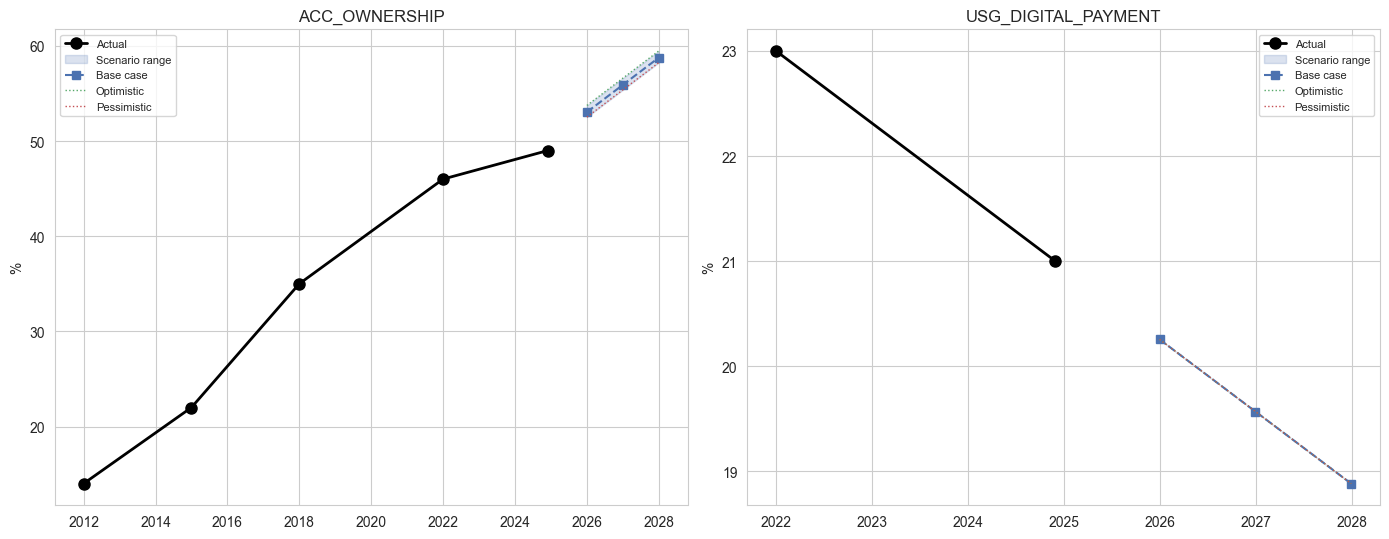

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (indicator, series, scenarios, trend) in zip(axes, [
    ("ACC_OWNERSHIP", acc_series, acc_scenarios, acc_trend),
    ("USG_DIGITAL_PAYMENT", usg_series, usg_scenarios, usg_trend),
]):
    ax.plot(series["observation_date"], series["value_numeric"], marker="o", markersize=8,
            color="black", linewidth=2, label="Actual", zorder=5)

    pivot = scenarios.pivot(index="year", columns="scenario", values="forecast")
    forecast_dates = [pd.Timestamp(f"{y}-12-31") for y in pivot.index]

    ax.fill_between(forecast_dates, pivot["pessimistic"], pivot["optimistic"],
                     alpha=0.2, color="#4c72b0", label="Scenario range")
    ax.plot(forecast_dates, pivot["base"], marker="s", linestyle="--", color="#4c72b0", label="Base case")
    ax.plot(forecast_dates, pivot["optimistic"], linestyle=":", color="#55a868", linewidth=1, label="Optimistic")
    ax.plot(forecast_dates, pivot["pessimistic"], linestyle=":", color="#c44e52", linewidth=1, label="Pessimistic")

    ax.set_title(indicator)
    ax.set_ylabel("%")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "forecast_scenarios.png", dpi=150)
plt.show()


## Quantify Uncertainty

Combining the trend regression's statistical confidence interval with the scenario range
gives a fuller picture than either alone — the trend CI captures noise around the historical
fit, the scenario range captures structural uncertainty in the event-effect model.


In [10]:
def build_forecast_table(indicator_code, trend_df, scenario_df):
    pivot = scenario_df.pivot(index="year", columns="scenario", values="forecast")
    table = trend_df[["year", "trend_forecast", "ci_lower", "ci_upper"]].merge(pivot, on="year")
    table.insert(0, "indicator", indicator_code)
    return table

acc_table = build_forecast_table("ACC_OWNERSHIP", acc_trend, acc_scenarios)
usg_table = build_forecast_table("USG_DIGITAL_PAYMENT", usg_trend, usg_scenarios)
forecast_table = pd.concat([acc_table, usg_table], ignore_index=True).round(2)

forecast_table.to_csv(PROCESSED_DIR / "forecast_2025_2027.csv", index=False)
forecast_table


,indicator,year,trend_forecast,ci_lower,ci_upper,base,optimistic,pessimistic
0,ACC_OWNERSHIP,2025,54.72,42.43,67.00,53.03,53.74,52.51
1,ACC_OWNERSHIP,2026,57.58,44.78,70.38,55.90,56.60,55.37
2,ACC_OWNERSHIP,2027,60.44,47.08,73.80,58.76,59.46,58.24
3,USG_DIGITAL_PAYMENT,2025,20.32,NaN,NaN,20.26,20.26,20.26
4,USG_DIGITAL_PAYMENT,2026,19.64,NaN,NaN,19.57,19.57,19.57
5,USG_DIGITAL_PAYMENT,2027,18.95,NaN,NaN,18.88,18.88,18.88


**Explicit limitations, not just a disclaimer**:
- `USG_DIGITAL_PAYMENT`'s trend CI is statistically close to meaningless (2 points, ~0
  residual degrees of freedom) — its scenario range is doing almost all the real
  uncertainty-representation work for that indicator, not the CI column.
- The scenario range itself is only as good as Task 3's single validation case
  (Telebirr → `ACC_MM_ACCOUNT`) — it has not been cross-validated against a second
  independent event/indicator pair, because the data doesn't currently support one.
- Neither model accounts for a future Findex survey round changing methodology or
  definitions (has happened between rounds historically), or for a shock event (e.g. a
  new major regulatory change) not yet in the `event` catalog.


## Interpret Results

**What does the model predict?**


In [11]:
print("ACCOUNT OWNERSHIP (Access):")
for _, row in acc_table.iterrows():
    print(f"  {int(row['year'])}: base {row['base']:.1f}% "
          f"(range {row['pessimistic']:.1f}%-{row['optimistic']:.1f}%, trend CI {row['ci_lower']:.1f}-{row['ci_upper']:.1f}%)")

print("\nDIGITAL PAYMENT ADOPTION (Usage):")
for _, row in usg_table.iterrows():
    print(f"  {int(row['year'])}: base {row['base']:.1f}% "
          f"(range {row['pessimistic']:.1f}%-{row['optimistic']:.1f}%, trend CI {row['ci_lower']:.1f}-{row['ci_upper']:.1f}%)")


ACCOUNT OWNERSHIP (Access):
  2025: base 53.0% (range 52.5%-53.7%, trend CI 42.4-67.0%)
  2026: base 55.9% (range 55.4%-56.6%, trend CI 44.8-70.4%)
  2027: base 58.8% (range 58.2%-59.5%, trend CI 47.1-73.8%)

DIGITAL PAYMENT ADOPTION (Usage):
  2025: base 20.3% (range 20.3%-20.3%, trend CI nan-nan%)
  2026: base 19.6% (range 19.6%-19.6%, trend CI nan-nan%)
  2027: base 18.9% (range 18.9%-18.9%, trend CI nan-nan%)


**What events have the largest potential impact?** For **Access**
(`ACC_OWNERSHIP`), per the ranking above, Telebirr's launch and the Fayda Digital ID rollout
carry the largest calibrated effects (+3.4pp and +1.7pp respectively) — but both are
`literature`-based, comparable-country-derived estimates, not Ethiopia-specific empirical
findings, so treat the ranking as indicative, not precise.

**A real gap, found by running this and worth stating plainly rather than glossing over**:
**zero `impact_link` records target `USG_DIGITAL_PAYMENT` directly** — existing links target
related-but-different Usage indicators (`USG_P2P_COUNT`, `USG_MPESA_ACTIVE`, etc.), not this
specific aggregate code. That means the Usage event-augmented forecast above has **no event
boost at all** — it's pure trend extrapolation. Combined with the Usage trend being fit on
only 2 points, one of which (`2021: ~23%`) was itself an imprecise "fewer than one in four"
estimate (Task 1), the **downward-sloping Usage forecast (20.3%→18.9%) should be treated with
real skepticism** — it may just be noise between two uncertain points, not a genuine declining
trend. This is a concrete, actionable Task-1-style gap: a future enrichment pass should add
impact_links connecting Telebirr/M-Pesa/EthioPay to `USG_DIGITAL_PAYMENT` specifically, not
just to its component indicators.

**Key uncertainties, ranked:**
1. **The dampening factor itself** (0.15-0.6 scenario range) — calibrated from one historical
   case, this is the single largest lever in the Access forecast.
2. **`USG_DIGITAL_PAYMENT` has no event-model coverage and only 2 base data points** — its
   forecast is the least reliable number in this entire notebook, despite looking as precise
   as Access's in the table.
3. **No allowance for a 6th Findex survey round changing methodology** or for genuinely new,
   uncatalogued events between now and 2027.
4. **The registered-vs-active gap** (Task 2) suggests Access growth could remain structurally
   slow even if mobile money keeps expanding — the model doesn't have a mechanism to represent
   "more registered accounts without more genuinely new adopters," beyond what the calibrated
   dampening factor already implicitly captures.
